In [56]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
from plotly.subplots import make_subplots
import plotly.graph_objects as go

torch.manual_seed(12345)

class LinearToyModel(nn.Module):
  # Parameters from the paper: n = 20, m = 5, I_i = 0.7 ** i
  # Note: Some of these parameters differ for certain graphs

  def __init__(self, m=5, n=20, n_batches = 5, feature_probability = 0.3):
    super().__init__()
    self.n_batches = n_batches
    if torch.cuda.is_available():
      self.device = 'cuda'
    else:
      self.device = 'cpu'
    self.feature_probability = feature_probability
    self.n = n
    self.W = nn.Parameter(torch.randn((m,n),device=self.device))
    self.b = nn.Parameter(torch.randn((n,),device=self.device))
    self.i = (0.7 ** torch.arange(self.n)).to(self.device)


# Generating a sparse tensor of random values between 0 and 1 where only 10% of values are > 0
  def forward(self, x):
    h = x @ self.W.T # Encoder
    x2 = (h @ self.W) + self.b
    return x2

  def generate_data(self):
    feat = torch.rand(self.n_batches,self.n, device=self.W.device)

    # This is like an if statement.
    # We are making a tensor where each element has 30% chance of showing element from our feat tensor and 70% chance of showing 0

    batch = torch.where(
        torch.rand(self.n_batches,self.n, device=self.W.device) < self.feature_probability,
        feat,
        torch.zeros(self.n_batches,self.n, device=self.W.device),
    )

    return batch

In [57]:

class ReLUToyModel(nn.Module):
  # Parameters from the paper: n = 20, m = 5, I_i = 0.7 ** i
  def __init__(self, m=5, n=20, n_batches = 1024, feature_probability = torch.ones(()), importance =  (0.7 ** torch.arange(5)).to('cuda')
):
    super().__init__()
    self.n_batches = n_batches
    if torch.cuda.is_available():
      self.device = 'cuda'
    else:
      self.device = 'cpu'
    self.feature_probability = feature_probability.to(self.device)
    self.n = n
    self.W = nn.Parameter(torch.empty((m,n),device = self.device))
    nn.init.xavier_normal_(self.W)
    self.b = nn.Parameter(torch.zeros((n,),device = self.device))
    self.i = importance

# Generating a sparse tensor of random values between 0 and 1 where only 10% of values are > 0
  def forward(self, x):
    h = x @ self.W.T # Encoder. We are multiplying out [n_batch,n_features] tensor by [n_features,n_dimensions] tensor to get [n_batch,n_dimensions]
    nonlin = nn.ReLU()
    x2 = (h @ self.W) + self.b # [n_batch,n_dimensions] tensor by [n_dimensions,n_features] to get [n_batch,n_features]
    return nonlin(x2)

  def generate_data(self):
    feat = torch.rand(self.n_batches,self.n, device=self.W.device)

    # This is like an if statement.
    # We are making a tensor where each element has 30% chance of showing element from our feat tensor and 70% chance of showing 0

    batch = torch.where(
        torch.rand(self.n_batches,self.n, device=self.W.device) < self.feature_probability,
        feat,
        torch.zeros(self.n_batches,self.n, device=self.W.device),
    )

    return batch

In [58]:
def train(model):
  optim = torch.optim.AdamW([model.W, model.b], lr=1e-2)

  for step in range(10000):
    optim.zero_grad()
    batch = model.generate_data()
    out = model(batch)
    loss = (model.i*(batch - out) ** 2).mean()

    loss.backward()
    optim.step()
    if step % 1000 == 0:
      print("loss: ",loss)


In [59]:
# Code for this  mostly taken verbatim from Anthropic's implementation.
# I have decided to only train one model however for simplification

def intro_diagram(model):
  from matplotlib import colors  as mcolors
  from matplotlib import collections  as mc
  WA = model.W.detach()
  plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.viridis(model.i.cpu().numpy()))
  plt.rcParams['figure.dpi'] = 200
  N = len(WA[:,0])
  W = WA.cpu().detach().numpy().T
  fig, ax = plt.subplots(figsize=(2,2))
  colors = [mcolors.to_rgba(c)
            for c in plt.rcParams['axes.prop_cycle'].by_key()['color']]
  ax.scatter(W[:,0], W[:,1], c=colors[0:len(W[:,0])])
  ax.add_collection(mc.LineCollection(np.stack((np.zeros_like(W),W), axis=1), colors=colors))
  z = 1.5
  ax.set_facecolor('#FCFBF8')
  ax.set_xlim((-z,z))
  ax.set_ylim((-z,z))
  ax.tick_params(left = True, right = False , labelleft = False ,
                  labelbottom = False, bottom = True)
  for spine in ['top', 'right']:
      ax.spines[spine].set_visible(False)
  for spine in ['bottom','left']:
      ax.spines[spine].set_position('center')
  plt.show()



loss:  tensor(2.1513, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0160, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0289, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0307, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0103, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0291, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0055, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0121, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0054, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0063, device='cuda:0', grad_fn=<MeanBackward0>)


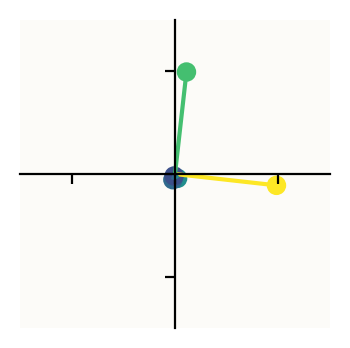

In [60]:
model = LinearToyModel(m=2,n=5)
train(model)
intro_diagram(model)

loss:  tensor(0.1056, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0176, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0180, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0184, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0175, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0188, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0179, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0179, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0180, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0175, device='cuda:0', grad_fn=<MeanBackward0>)


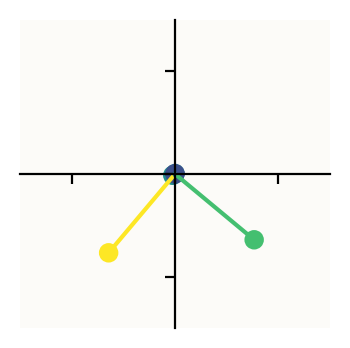

In [61]:
model = ReLUToyModel(n=5,m=2)
train(model)
intro_diagram(model)

In [62]:
def render_features(model):
  W = model.W.detach()
  W_norm = W / (1e-5 + torch.linalg.norm(W,2,dim=0,keepdim=True))

  # Start with 20x5 matrix. Matrix multiply with 5x20 matrix. Get 20x20 matrix
  # This is essentially getting the dot product of each feature so we can see how they interfere
  # Done through this way rather than the einsum way for simplicity. May change later.
  interference = W_norm.T @ W
  interference[torch.arange(model.n),torch.arange(model.n)] = 0 # This code sets the diagonal of our matrix to 0 because these will just be the interference of a feature with itself

  polysemanticity = torch.linalg.norm(interference,2, dim=0).cpu()

  net_interference = (interference **2 * model.feature_probability).sum(-1)
  norms = torch.linalg.norm(W,2,dim=0).cpu()
  WtW = W.T @ W
  x = torch.arange(model.n)

  # Like with the last graph, my implementation is significantly simplified due to only including one model
  # Again, a lot of this code it taken verbatim from Anthropic's implementation so I can get similar graphs
  fig = make_subplots(rows=2, cols=1)
  fig.add_trace(
    go.Bar(x=x, y=norms, marker=dict(color=polysemanticity,cmin=0,cmax=1),width = 0.9), row=1, col=1
  )
  data = WtW.cpu().detach().numpy()
  fig.add_trace(
     go.Image(
            z=plt.cm.coolwarm((1 + data)/2, bytes=True),
            colormodel='rgba256',
            customdata=data,
            hovertemplate='''\
  In: %{x}<br>
  Out: %{y}<br>
  Weight: %{customdata:0.2f}
  ''' ),row=2, col=1,)
  fig.add_vline(
    x=(x[model.W.shape[0]-1] + x[model.W.shape[0]]) / 2,
    line=dict(width=0.5),
    col=1,
    row=1
)
  fig.update_layout(showlegend=False,
                    width=600,
                    height=600,
                    margin=dict(t=0, b=0))
  fig.update_xaxes(visible=False)
  fig.update_yaxes(visible=False)
  return fig

In [64]:
model = ReLUToyModel(m=20,n=100, feature_probability= torch.tensor(0.2236), importance = 100 ** (-torch.linspace(0, 1, 100)).to('cuda'))
train(model)
print(model.W)
fig = render_features(model)
fig.update_layout()

loss:  tensor(0.0114, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0036, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0035, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0036, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0037, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0035, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0035, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0036, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0035, device='cuda:0', grad_fn=<MeanBackward0>)
loss:  tensor(0.0037, device='cuda:0', grad_fn=<MeanBackward0>)
Parameter containing:
tensor([[ 4.6394e-01, -4.3463e-02, -2.1656e-01,  ..., -8.5649e-04,
          2.4442e-03, -1.7927e-03],
        [ 2.6434e-01,  2.8622e-01,  3.5827e-01,  ..., -2.3221e-04,
          6.4199e-03,  1.7075e-03],
        [-3.2507e-01, -2.6963e-02,  4.1929e-03,  ...,  4.2426e-03,
          5.4907e-04,  9.8861e-04],
        ...,
        [ 2.1297